## Detecção de Fraudes em Transações (Cartão de crédito)

##### Bibliotecas essenciais

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

### Importando o dataset

In [67]:
import kagglehub

path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Path to dataset files:", path)

Path to dataset files: /home/ruanrdg/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1


### Carregando os dados

In [68]:
df =  pd.read_csv("fraudTrain.csv")

In [69]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### Entendendo o dataset

In [70]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [71]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [72]:
total_fraudes = df.is_fraud.value_counts().sum()
counts = df.is_fraud.value_counts()
print("Quantidade de fraudes: ", total_fraudes)
percentagens = df['is_fraud'].value_counts(normalize=True) * 100
for val, count in counts.items():
        pct = percentagens[val]
        print(f"Classe {val}: {count:,} ({pct:.4f}%)")

Quantidade de fraudes:  1296675
Classe 0: 1,289,169 (99.4211%)
Classe 1: 7,506 (0.5789%)


Como podemos ver,  apenas 0.58% das transações nesse dataset são fraudulentas

### Limpando os dados

In [73]:
df.isnull().value_counts()

Unnamed: 0  trans_date_trans_time  cc_num  merchant  category  amt    first  last   gender  street  city   state  zip    lat    long   city_pop  job    dob    trans_num  unix_time  merch_lat  merch_long  is_fraud
False       False                  False   False     False     False  False  False  False   False   False  False  False  False  False  False     False  False  False      False      False      False       False       1296675
Name: count, dtype: int64

Sem valores nulos no dataset

In [74]:
df.drop("Unnamed: 0", inplace = True, axis= 1)

In [75]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


### Entendendo os dados

Vejamos como estão distribuídas as categorias entre todas as transações

In [76]:
df.category.value_counts()

category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64

Temos 14 categorias diferentes, analisaremos o quão distribuídas estão as fraudes entre essas categorias

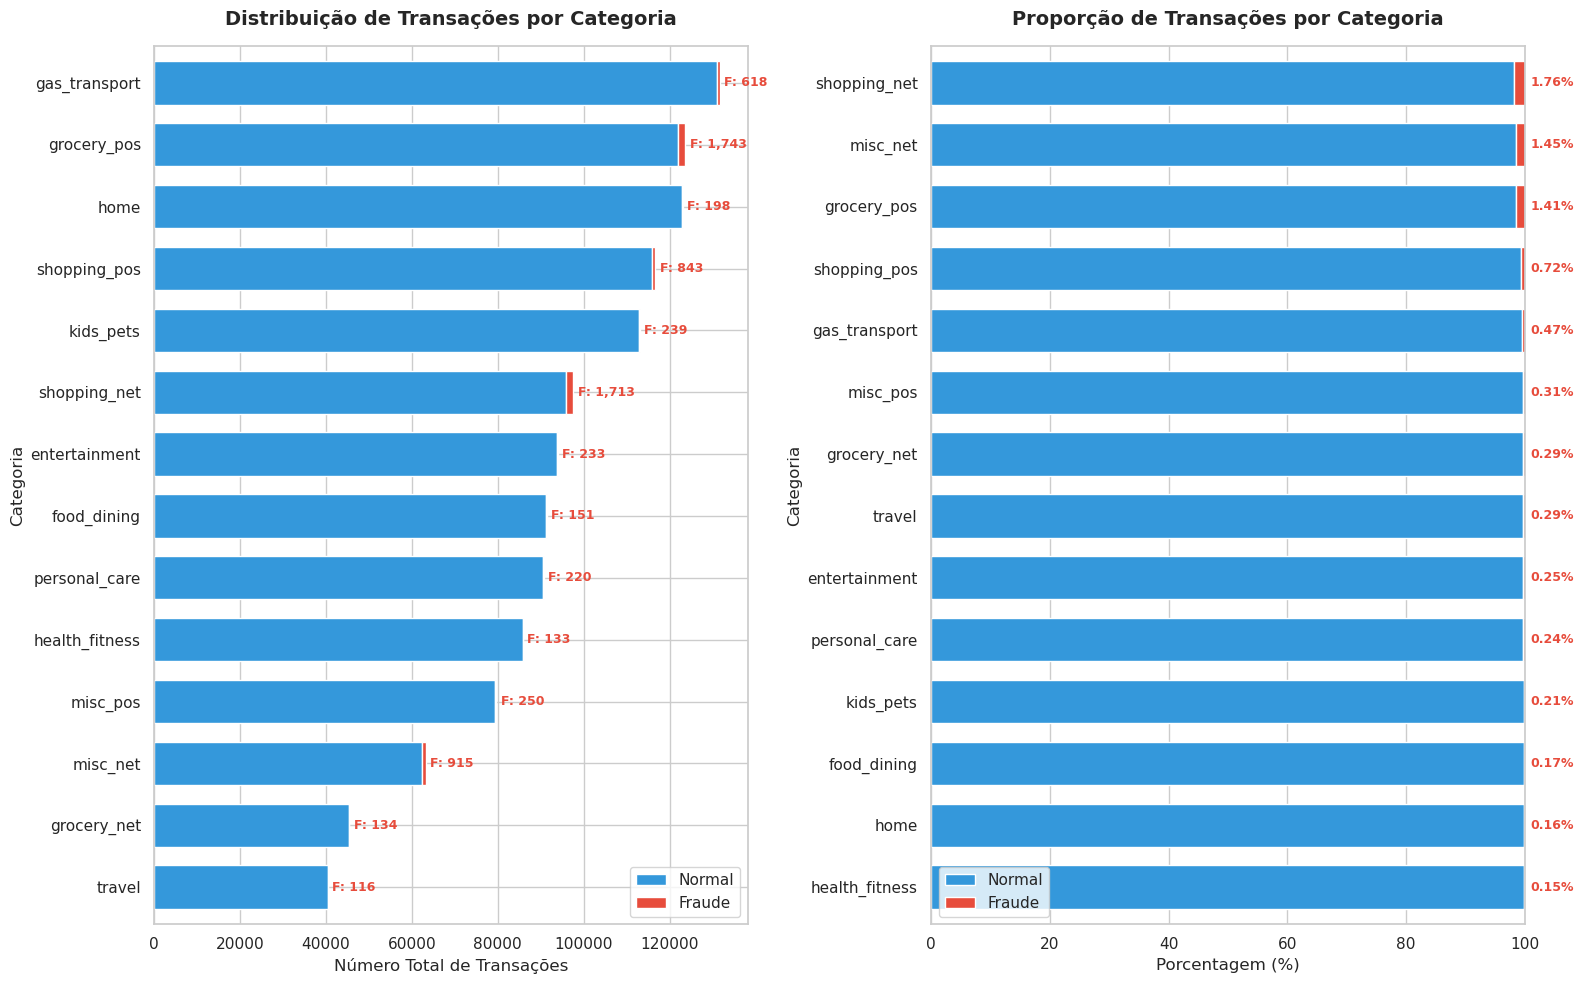

In [77]:
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# Preparação dos dados
pivot_df = df.groupby(['category', 'is_fraud']).size().unstack(fill_value=0)
pivot_df['total'] = pivot_df[0] + pivot_df[1]
pivot_df_sorted = pivot_df.sort_values(by='total', ascending=True)

# Calcular porcentagens
pivot_pct = pivot_df[[0, 1]].div(pivot_df['total'], axis=0) * 100
pivot_pct_sorted = pivot_pct.sort_values(by=1, ascending=True)

colors = ['#3498db', '#e74c3c']

#Distribuição Absoluta
pivot_df_sorted[[0, 1]].plot(kind='barh', stacked=True, color=colors, ax=ax1, width=0.7)
ax1.set_title("Distribuição de Transações por Categoria", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Número Total de Transações", fontsize=12)
ax1.set_ylabel("Categoria", fontsize=12)
ax1.legend(["Normal", "Fraude"], loc="lower right", frameon=True)

# Anotações de quantidade de fraudes ao lado das barras
for i, (cat, row) in enumerate(pivot_df_sorted.iterrows()):
    total = row['total']
    fraud = row[1]
    ax1.text(total + 1000, i, f"F: {fraud:,}", va='center', fontsize=9, fontweight='bold', color='#e74c3c')

#Proporção Relativa
pivot_pct_sorted[[0, 1]].plot(kind='barh', stacked=True, color=colors, ax=ax2, width=0.7)
ax2.set_title("Proporção de Transações por Categoria", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Porcentagem (%)", fontsize=12)
ax2.set_ylabel("Categoria", fontsize=12)
ax2.set_xlim(0, 100)
ax2.legend(["Normal", "Fraude"], loc="lower left", frameon=True)

#Anotações de porcentagem de fraudes ao lado das barras
for i, (cat, row) in enumerate(pivot_pct_sorted.iterrows()):
    pct_fraud = row[1]
    ax2.text(101, i, f"{pct_fraud:.2f}%", va='center', fontsize=9, fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.savefig("category_vs_fraud_comparison.png", bbox_inches="tight", dpi=150)
plt.show()


Analisando o gráfico de proporção de transações fraudulentas por categorias, podemos observar que compras pela internet possuem a maior proporção de fraudes (cerca de 1.5% para as categorias shopping e outros), seguido de compras em mercados.

A relação entre valor de transação e fraudes

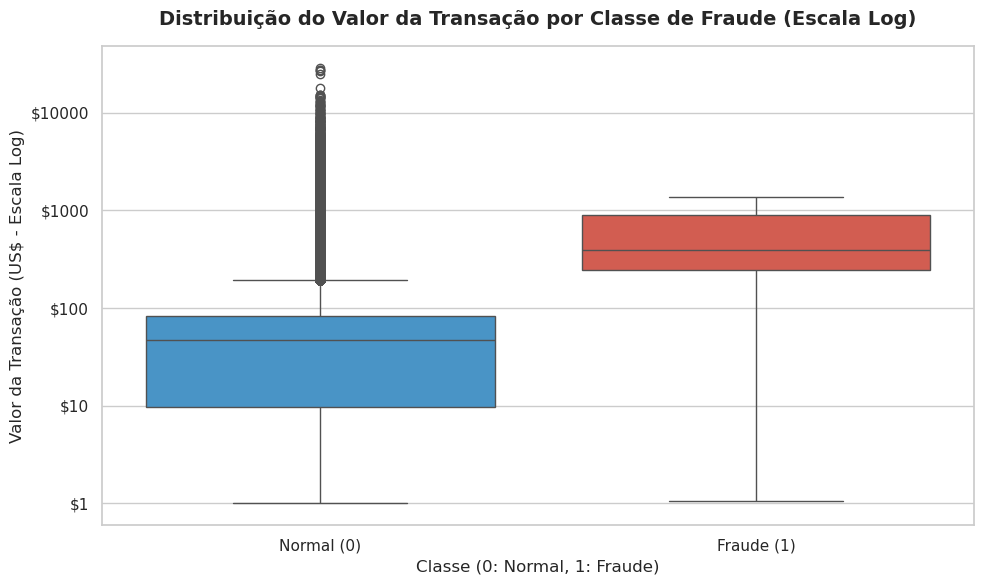

In [78]:
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(10, 6))  
 
# Box plot comparando normal e fraude
ax = sns.boxplot(
x="is_fraud",
y="amt", 
data=df, 
palette=["#3498db", "#e74c3c"],  
hue="is_fraud",  
legend=False 
)
 
# Ajustando escala e rótulos 
plt.yscale("log")
plt.title("Distribuição do Valor da Transação por Classe de Fraude (Escala Log)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Classe (0: Normal, 1: Fraude)", fontsize=12) 
plt.ylabel("Valor da Transação (US$ - Escala Log)", fontsize=12) 
plt.xticks([0, 1], ["Normal (0)", "Fraude (1)"])   

# Formatar o eixo Y para exibir cifrão
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("$%g"))

plt.tight_layout()
plt.savefig("amt_vs_fraud_boxplot.png", bbox_inches="tight", dpi=150)
plt.show()

Como podemos ver, as transações fraudulentas, em sua maioria, estão concentradas entre 400$ a 1000$, com uma média de aproximadamente 650$

Vejamos agora como as fraudes se distribuem através dos dados temporais que temos disponíveis

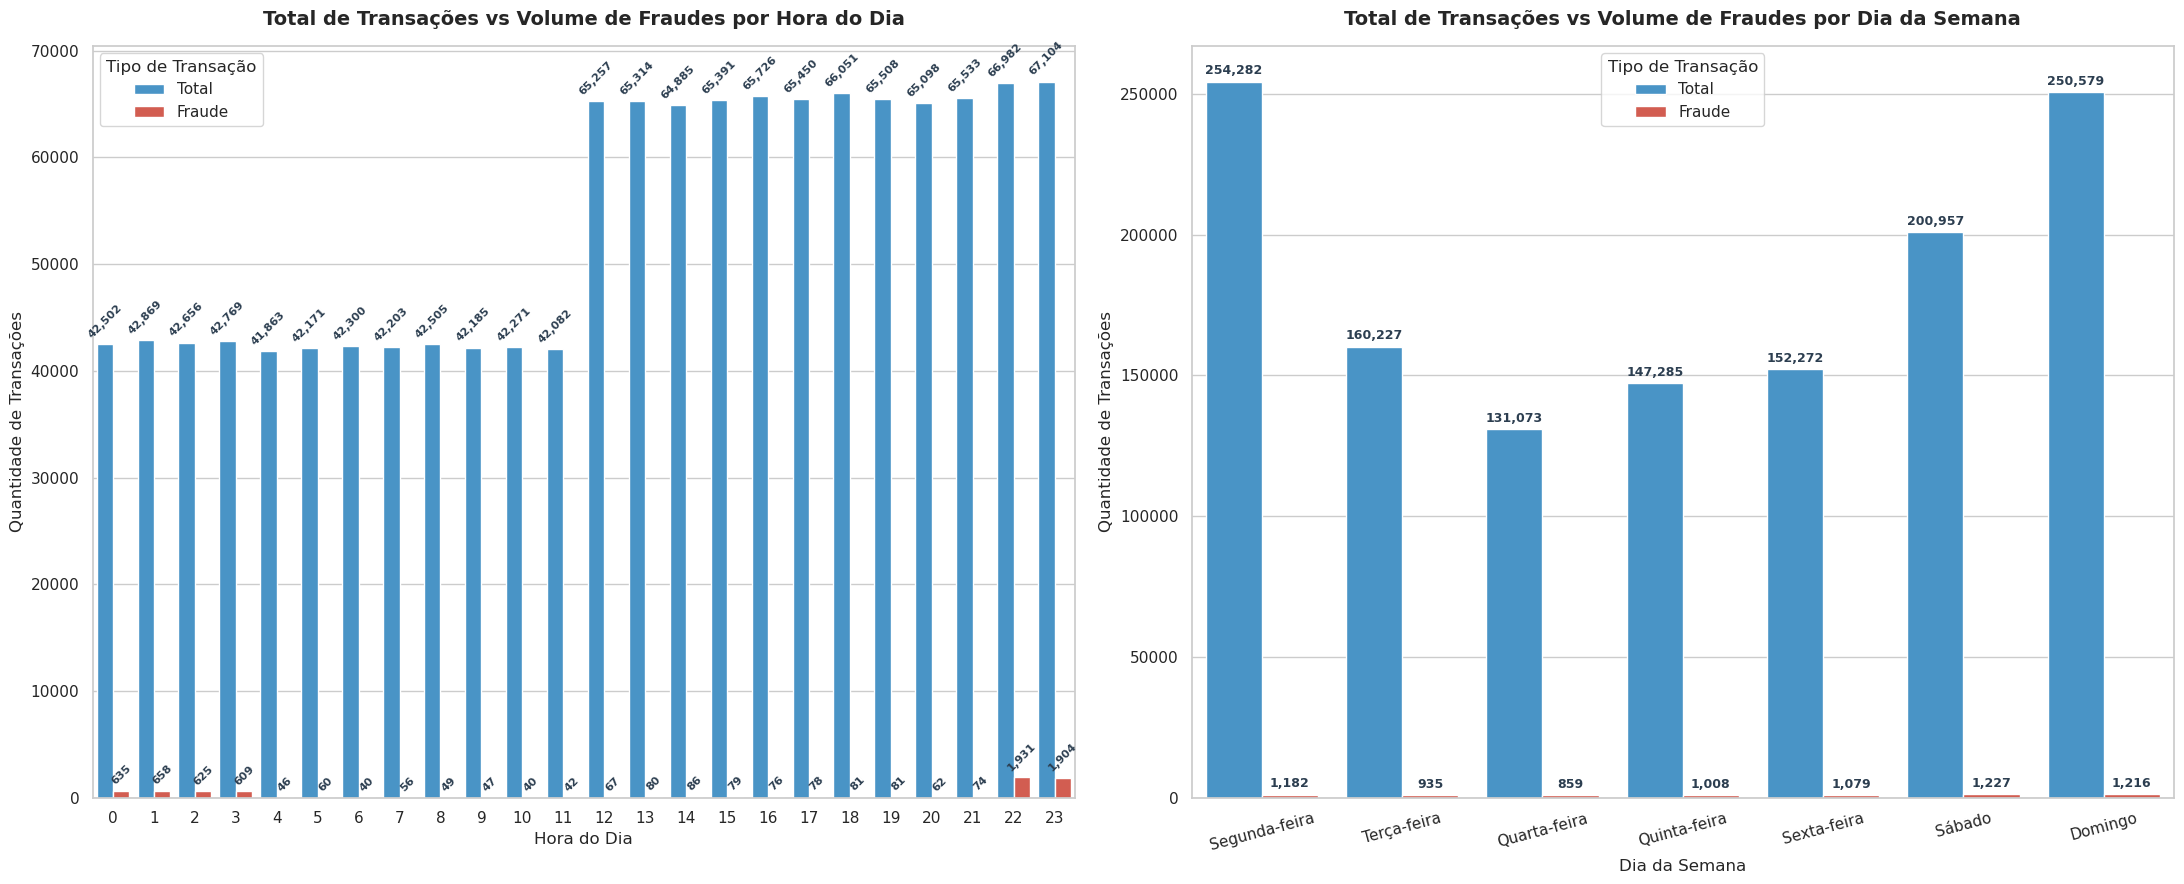

In [79]:
# Análise Temporal: Volume de Fraudes por Hora do Dia e Dia da Semana com Barras Lado a Lado

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configurações Iniciais e Conversão de Datetime
if not pd.api.types.is_datetime64_any_dtype(df['trans_date_trans_time']):
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extração de recursos temporais
df['hour'] = df['trans_date_trans_time'].dt.hour
day_order = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek.map(lambda x: day_order[x])

sns.set_theme(style="whitegrid")
colors = ['#3498db', '#e74c3c']  # Azul para Total, Vermelho para Fraude

# 2. Agrupamento e preparação dos dados do Subplot 1 (Hora)
hour_total = df.groupby('hour').size()
hour_fraud = df.groupby('hour')['is_fraud'].sum()

df_hour = pd.DataFrame({
    'Hora': list(hour_total.index) * 2,
    'Quantidade': list(hour_total.values) + list(hour_fraud.values),
    'Tipo': ['Total'] * 24 + ['Fraude'] * 24
})

# 3. Agrupamento e preparação dos dados do Subplot 2 (Dia)
day_total = df.groupby('day_of_week').size().reindex(day_order)
day_fraud = df.groupby('day_of_week')['is_fraud'].sum().reindex(day_order)

df_day = pd.DataFrame({
    'Dia da Semana': list(day_total.index) * 2,
    'Quantidade': list(day_total.values) + list(day_fraud.values),
    'Tipo': ['Total'] * 7 + ['Fraude'] * 7
})

# 4. Criação da figura com dois subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# ----------------------------------------------------
# Subplot 1: Total vs Fraudes por Hora do Dia
# ----------------------------------------------------
sns.barplot(data=df_hour, x='Hora', y='Quantidade', hue='Tipo', palette=colors, ax=ax1)
ax1.set_title("Total de Transações vs Volume de Fraudes por Hora do Dia", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Hora do Dia", fontsize=12)
ax1.set_ylabel("Quantidade de Transações", fontsize=12)
ax1.set_xticks(range(24))
ax1.legend(title="Tipo de Transação")

# Rótulos de valor exato acima de cada barra (Hora)
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{int(height):,}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=8, fontweight='bold', color='#2c3e50',
                     xytext=(0, 3), textcoords='offset points', rotation=45)

#Total vs Fraudes por Dia da Semana
sns.barplot(data=df_day, x='Dia da Semana', y='Quantidade', hue='Tipo', palette=colors, ax=ax2)
ax2.set_title("Total de Transações vs Volume de Fraudes por Dia da Semana", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Dia da Semana", fontsize=12)
ax2.set_ylabel("Quantidade de Transações", fontsize=12)
ax2.tick_params(axis='x', rotation=15)
ax2.legend(title="Tipo de Transação")

# Rótulos de valor exato acima de cada barra (Dia)
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(f'{int(height):,}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2c3e50',
                     xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.savefig("temporal_fraud_volume.png", bbox_inches="tight", dpi=150)
plt.show()


As quantidades de transações fraudulentas entre 22h e 3h da manhã são muito maiores do que em outros períodos do dia. Entretanto, observando os dias da semana, o número de fraudes parece não ser correlato com a quantidade de fraudes em cada dia

#### Transformação e Seleção de features

Vimos que informações como a hora do dia, junto com a categoria de cada transação podem ser importantes para determinar se uma transação tende a ser fraudulenta ou não. Iremos separar a coluna trans_date_trans_time em horas e dias da semana para uma melhor interpretação do nosso modelo

In [80]:
# Extração da hora do dia
df['hour'] = df['trans_date_trans_time'].dt.hour

A distância entre a moradia do comprador e a localização da transação também pode ser um bom indicativo de fraude, pois se uma transação é feita num estado x, é pouco provável que uma transação presencial seja feita em outro estado y muito distante. Utilizaremos o método de Haversine para o cálculo dessa distância em km


In [81]:
def calcular_distancia_haversine(lat1, lon1, lat2, lon2):
    # Converte graus decimais para radianos
    lat1_rad, lon1_rad, lat2_rad, lon2_rad = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Diferença das coordenadas em radianos
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    # Fórmula de Haversine
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Raio médio da Terra em quilômetros
    r = 6371.0
    
    return c * r

# Adiciona a nova feature de distância ao DataFrame df
df['distance_km'] = calcular_distancia_haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

In [82]:
df['category'] = df['category'].astype('category')

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 25 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  category      
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat                    12966

#### Modelagem

Primeiro, vamos selecionar as features que iremos utilizar para o treinamento do modelo:

In [84]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day_of_week', 'distance_km'],
      dtype='object')

In [85]:
df = df.drop(['trans_date_trans_time', 'cc_num', 'merchant','first', 'last', 
            'gender', 'street', 'city', 'state', 'zip', 'lat',
            'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
            'merch_long','day_of_week'], axis = 1)

In [86]:
df.head()

,category,amt,is_fraud,hour,distance_km
0,misc_net,4.97,0,0,78.597568
1,grocery_pos,107.23,0,0,30.212176
2,entertainment,220.11,0,0,108.206083
3,gas_transport,45.00,0,0,95.673231
4,misc_pos,41.96,0,0,77.556744


Para esse problema, utilizaremos o algoritmo de XGBoost para a detecção das fraudes, separando o dataset em treino e teste com stratify, pois há um grande desbalanceamento entre as classes (apenas 0.58% de transações fraudulentas).

In [87]:
x = df.drop('is_fraud', axis =1)
y = df.is_fraud

In [88]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

Separando treino e teste em 80% e 20%, com stratify na variável target y (is_fraud)

##### Treinando o modelo

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

xgb_model = xgb.XGBClassifier(
    tree_method='hist',
    enable_categorical=True,
    random_state=42
)

param_grid = {
    'max_depth': [5, 7],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=1
)

grid_search.fit(x_train, y_train)
#Melhores: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
# Exibir melhores parâmetros
print("Melhores parâmetros encontrados:", grid_search.best_params_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=100; total time=   3.6s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=100; total time=   3.7s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=100; total time=   2.6s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=200; total time=   4.5s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=200; total time=   6.9s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=200; total time=   6.2s
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=100; total time=   4.5s
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=100; total time=   4.5s
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=100; total time=   3.8s
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=200; total time=   8.5s
[CV] END ...learning_rate=0.1, max_depth=7, n_estimators=200; total time=   7.1s
[CV] END ...learning_rate=0.1, max_depth=7, n_est

In [98]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score, confusion_matrix

best_model = grid_search.best_estimator_

# 1. Pegamos apenas as probabilidades da classe positiva (Fraude)
y_pred_proba = best_model.predict_proba(x_test)[:, 1]

novo_threshold = 0.33
y_pred_custom = (y_pred_proba >= novo_threshold).astype(int)

auc = roc_auc_score(y_test, y_pred_proba) 
f1 = f1_score(y_test, y_pred_custom)
recall = recall_score(y_test, y_pred_custom)

print(f"AVALIAÇÃO")
print(f"AUC-ROC Score : {auc:.6f}")
print(f"F1-Score      : {f1:.6f}")
print(f"Recall        : {recall:.6f}")

print("\nRelatório de Classificação Completo:")
print(classification_report(y_test, y_pred_custom, target_names=['Normal', 'Fraude']))

AVALIAÇÃO
AUC-ROC Score : 0.997368
F1-Score      : 0.774127
Recall        : 0.753498

Relatório de Classificação Completo:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    257834
      Fraude       0.80      0.75      0.77      1501

    accuracy                           1.00    259335
   macro avg       0.90      0.88      0.89    259335
weighted avg       1.00      1.00      1.00    259335



Precision: 0.80
De todas as transações que o modelo classificou como fraude, 80% eram crimes de verdade e 20% eram alarmes falsos (clientes legítimos).

Recall: 0.75
O modelo conseguiu capturar 75% de todas as fraudes reais que aconteceram no dataset, enquanto 25% passaram sem detecção.

F1-Score: 0.77
Resume o equilíbrio entre as duas métricas acima

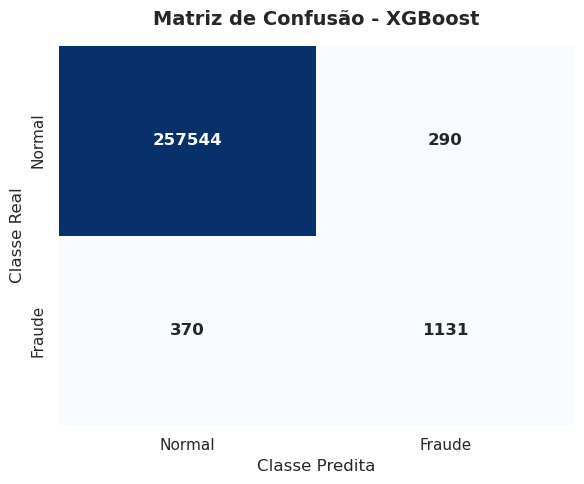

In [ ]:
from sklearn.metrics import confusion_matrix
#matriz de confusão
cm = confusion_matrix(y_test, y_pred_custom)

#Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Normal', 'Fraude'], 
    yticklabels=['Normal', 'Fraude'],
    cbar=False,
    annot_kws={"fontsize": 12, "weight": "bold"}
)
plt.title('Matriz de Confusão - XGBoost', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_xgboost.png", bbox_inches="tight", dpi=150)
plt.show()

Das 1501 transações fraudulentas no set de teste, 1131 foram classificadas corretamente e 370 passaram como transação normal, além de 290 transações como falso-positivas

###### Nota: Utilizei SMOTE para a geração de dados sintéticos para tentar melhorar as métricas de precisão mas ocorreu uma piora nas métricas de recall e consequentemente na F1, testei o XGBoost com peso de 171.7 (Nº de transações normais/Nº transações fraudulentas) nas transações fraudulentas antes do treinamento e também ocorreu uma piora nas métricas. Mantive apenas o GridSearch para buscar os melhores parâmetros possíveis e setei um threshold de 0.33 em cima do score do modelo para uma melhor classificação dessas transações.